<a href="https://colab.research.google.com/github/GilliardMorandim/mba-tcc-usp-inadimplencia/blob/eda%2Ffeature/eda_%5BMBA%5D_TCC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Requirements

In [2]:
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!pip install pyspark


In [5]:
import matplotlib.pyplot as plt
from google.colab import drive
import os
import pandas as pd

# Montagem do Google Drive

In [4]:
drive.mount('/content/drive')


Mounted at /content/drive


# Acesso ao Arquivo

In [6]:
import os
import pandas as pd

In [7]:
# 2. Caminho para o diretório
base_path = "/content/drive/MyDrive/MBA - Ciencia de Dados - USP/dados_tcc/"

# 3. Listar todos os arquivos CSV
files = [f for f in os.listdir(base_path) if f.endswith(".csv")]

print("Arquivos encontrados:")
for f in files:
    print("-", f)

# 4. Ler todos os CSVs em um dicionário
dataframes = {}

for f in files:
    full_path = os.path.join(base_path, f)
    print(f"\nLendo arquivo: {f} ...")

    try:
        df = pd.read_csv(full_path)
        dataframes[f.replace(".csv", "")] = df
        print(f"✓ OK! Linhas: {df.shape[0]}  |  Colunas: {df.shape[1]}")
    except Exception as e:
        print(f"Erro ao ler {f}: {e}")

        try:
          df = pd.read_csv(full_path, engine="python",on_bad_lines="skip")
          dataframes[f.replace(".csv", "")] = df
          print(f"✓ OK, lido com skip! Linhas: {df.shape[0]}  |  Colunas: {df.shape[1]}")
        except Exception as e:
          print(f"Erro ao ler {f}: {e}")


# 5. Exemplo de acesso
#df_analise = dataframes["analise_conversao"]
#df_analise.head()

Arquivos encontrados:
- pre_aprovado.csv
- parcelas.csv
- contratos.csv
- score_credito.csv
- analise_conversao.csv
- analise_conversao_v2.csv
- analise_conversao_v3.csv

Lendo arquivo: pre_aprovado.csv ...
✓ OK! Linhas: 42171363  |  Colunas: 11

Lendo arquivo: parcelas.csv ...


/tmp/ipython-input-149913569.py:19: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)


✓ OK! Linhas: 1865444  |  Colunas: 21

Lendo arquivo: contratos.csv ...


/tmp/ipython-input-149913569.py:19: DtypeWarning: Columns (18,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)


✓ OK! Linhas: 382539  |  Colunas: 26

Lendo arquivo: score_credito.csv ...
✓ OK! Linhas: 266126  |  Colunas: 3

Lendo arquivo: analise_conversao.csv ...
Erro ao ler analise_conversao.csv: Error tokenizing data. C error: Expected 12 fields in line 447, saw 13

✓ OK, lido com skip! Linhas: 509820  |  Colunas: 12

Lendo arquivo: analise_conversao_v2.csv ...
Erro ao ler analise_conversao_v2.csv: Error tokenizing data. C error: Expected 12 fields in line 447, saw 13

✓ OK, lido com skip! Linhas: 509820  |  Colunas: 12

Lendo arquivo: analise_conversao_v3.csv ...
Erro ao ler analise_conversao_v3.csv: Error tokenizing data. C error: Expected 11 fields in line 312, saw 13

✓ OK, lido com skip! Linhas: 504684  |  Colunas: 11


# Lendo Arquivo Pyspark

In [7]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
         .appName("LoadAllCSVs")
         .config("spark.driver.memory", "8g")
         .config("spark.executor.memory", "8g")
         .config("spark.sql.files.maxPartitionBytes", "256m")
         .getOrCreate())

print("Spark iniciado!")

Spark iniciado!


In [9]:
dfs_spark = {}

base_path = "/content/drive/MyDrive/MBA - Ciencia de Dados - USP/dados_tcc/"

files = [f for f in os.listdir(base_path) if f.endswith(".csv")]

for file in files:
    full_path = os.path.join(base_path, file)
    print(f"\n📥 Lendo via PySpark: {file}")

    try:
        df = (spark.read
              .option("header", "true")
              .option("inferSchema", "true")
              .csv(full_path))

        key = file.replace(".csv", "")
        dfs_spark[key] = df

        print(f"✔ OK - Linhas (estimado pela Spark): {df.count()} | Colunas: {len(df.columns)}")

    except Exception as e:
        print(f"❌ Erro ao ler {file}: {e}")

print("\nTodos os arquivos foram processados!")


📥 Lendo via PySpark: pre_aprovado.csv
✔ OK - Linhas (estimado pela Spark): 42171363 | Colunas: 11

📥 Lendo via PySpark: parcelas.csv
✔ OK - Linhas (estimado pela Spark): 1865444 | Colunas: 21

📥 Lendo via PySpark: contratos.csv
✔ OK - Linhas (estimado pela Spark): 382539 | Colunas: 26

📥 Lendo via PySpark: score_credito.csv
✔ OK - Linhas (estimado pela Spark): 266126 | Colunas: 3

📥 Lendo via PySpark: analise_conversao.csv
✔ OK - Linhas (estimado pela Spark): 538023 | Colunas: 12

📥 Lendo via PySpark: analise_conversao_v2.csv
✔ OK - Linhas (estimado pela Spark): 538023 | Colunas: 12

📥 Lendo via PySpark: analise_conversao_v3.csv
✔ OK - Linhas (estimado pela Spark): 533525 | Colunas: 11

Todos os arquivos foram processados!


In [10]:
pre_aprovado = dfs_spark["pre_aprovado"]

In [11]:
globals().update(dfs_spark)

In [12]:
parcelas.show(5)

+--------------+---------------+--------------------+-------+---------+------------------------------+------------+-------------+------------+-----------+-----------+-----------------+----------+--------------+------------------+--------------------------+----------------+--------------------+-------+------------------+-------------------------------+
|data_pagamento|data_vencimento|         id_contrato|  valor|valor_iof|valor_financiado_principal_iof|qtd_parcelas|valor_parcela|valor_tarifa|valor_juros|valor_iof_2|valor_amortizacao|valor_pago|valor_desconto|valor_juros_atraso|valor_juros_remuneratorios|status_pagamento|          id_parcela|parcela|qtd_dias_de_atraso|contract_installments_status_id|
+--------------+---------------+--------------------+-------+---------+------------------------------+------------+-------------+------------+-----------+-----------+-----------------+----------+--------------+------------------+--------------------------+----------------+-------------------

In [28]:
parcelas_main = parcelas

contratos_keys = contratos.select(
    "id_contrato",
    "uuid_cliente",
    "id_contrato_original",
    "id_contrato_pai",
    "cpf_hash_sha256").filter("id_contrato IS NOT NULL")

#parcelas_main = parcelas_main.join(
 #   contratos_keys,
  #  parcelas_main.id_contrato == contratos_keys.id_contrato,
   # "left")

parcelas_main = parcelas.join(
    contratos_keys,
    on="id_contrato",
    how="left"
)

In [30]:
parcelas_main = parcelas_main.filter("data_vencimento < '2025-11-01'")

In [29]:
parcelas_main.columns

['id_contrato',
 'data_pagamento',
 'data_vencimento',
 'valor',
 'valor_iof',
 'valor_financiado_principal_iof',
 'qtd_parcelas',
 'valor_parcela',
 'valor_tarifa',
 'valor_juros',
 'valor_iof_2',
 'valor_amortizacao',
 'valor_pago',
 'valor_desconto',
 'valor_juros_atraso',
 'valor_juros_remuneratorios',
 'status_pagamento',
 'id_parcela',
 'parcela',
 'qtd_dias_de_atraso',
 'contract_installments_status_id',
 'uuid_cliente',
 'id_contrato_original',
 'id_contrato_pai',
 'cpf_hash_sha256']

In [31]:
#parcelas_main.show(5)
#1.865.442 ----> 1.063.816 ----> apos mudança da data de vencimento anterior a nov/2025
parcelas_main.count()

1063816

In [15]:
parcelas_main = parcelas_main.filter("cpf_hash_sha256 IS NOT NULL")
parcelas_main.count()

1865442

#Analise dataframe parcelas
- distribuição dos valores dos contratos
- distribuição do valor da parcela
- distribuição do valor_juros
- distribuição da quantidade de parcelas - pegar o máximo de cada id_contrato
- distribuição qtd_dias_de_atraso

In [ ]:
parcelas.columns

['data_pagamento',
 'data_vencimento',
 'id_contrato',
 'valor',
 'valor_iof',
 'valor_financiado_principal_iof',
 'qtd_parcelas',
 'valor_parcela',
 'valor_tarifa',
 'valor_juros',
 'valor_iof_2',
 'valor_amortizacao',
 'valor_pago',
 'valor_desconto',
 'valor_juros_atraso',
 'valor_juros_remuneratorios',
 'status_pagamento',
 'id_parcela',
 'parcela',
 'qtd_dias_de_atraso',
 'contract_installments_status_id']

In [15]:
parcelas_main.show(5)

+--------------------+--------------+---------------+-------+---------+------------------------------+------------+-------------+------------+-----------+-----------+-----------------+----------+--------------+------------------+--------------------------+----------------+--------------------+-------+------------------+-------------------------------+--------------------+--------------------+---------------+--------------------+
|         id_contrato|data_pagamento|data_vencimento|  valor|valor_iof|valor_financiado_principal_iof|qtd_parcelas|valor_parcela|valor_tarifa|valor_juros|valor_iof_2|valor_amortizacao|valor_pago|valor_desconto|valor_juros_atraso|valor_juros_remuneratorios|status_pagamento|          id_parcela|parcela|qtd_dias_de_atraso|contract_installments_status_id|        uuid_cliente|id_contrato_original|id_contrato_pai|     cpf_hash_sha256|
+--------------------+--------------+---------------+-------+---------+------------------------------+------------+-------------+-----

### Histograma valor do contrato

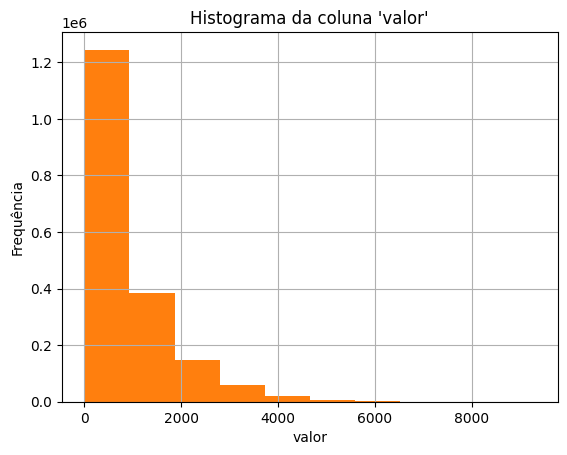

In [ ]:
# Assuming parcelas_main is available in the environment
try:
    # Convert only the 'valor' column to pandas
    parcelas_pd = parcelas_main.select("valor").toPandas()
    parcelas_pd = parcelas_pd[parcelas_pd["valor"] > 0]
    parcelas_pd.hist(bins=50)

    plt.hist(parcelas_pd["valor"].dropna())
    plt.xlabel("valor")
    plt.ylabel("Frequência")
    plt.title("Histograma da coluna 'valor'")
    plt.show()
except Exception as e:
    print("Erro ao gerar histograma:", e)

### Histograma valor da parcela

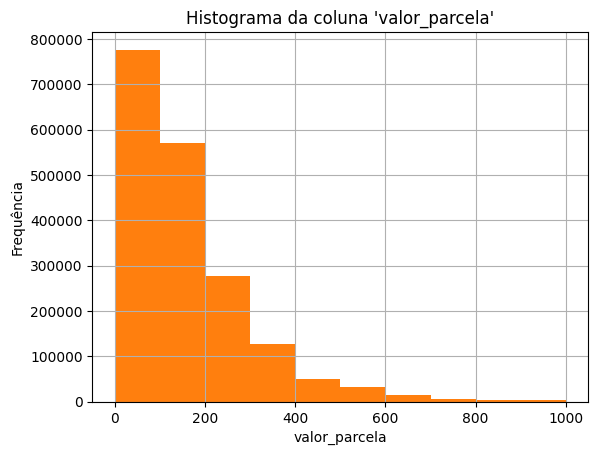

In [ ]:
try:
    # Convert only the 'valor' column to pandas
    parcelas_pd = parcelas_main.select("valor_parcela").toPandas()
    parcelas_pd = parcelas_pd[parcelas_pd["valor_parcela"] > 0]
    parcelas_pd = parcelas_pd[parcelas_pd["valor_parcela"] <= 1000]
    parcelas_pd.hist(bins=50)

    plt.hist(parcelas_pd["valor_parcela"].dropna())
    plt.xlabel("valor_parcela")
    plt.ylabel("Frequência")
    plt.title("Histograma da coluna 'valor_parcela'")
    plt.show()
except Exception as e:
    print("Erro ao gerar histograma:", e)

### Histograma valor dos juros

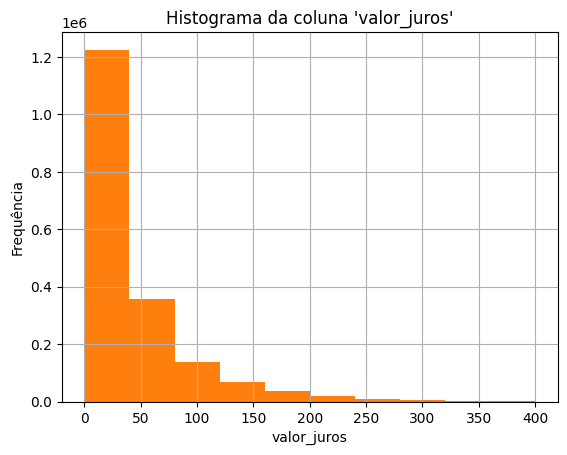

In [18]:
import matplotlib.pyplot as plt

# Assuming parcelas_main is available in the environment
try:
    # Convert only the 'valor' column to pandas
    parcelas_pd = parcelas_main.select("valor_juros").toPandas()
    parcelas_pd = parcelas_pd[parcelas_pd["valor_juros"] > 0]
    parcelas_pd = parcelas_pd[parcelas_pd["valor_juros"] <= 400]
    parcelas_pd.hist(bins=50)

    plt.hist(parcelas_pd["valor_juros"].dropna())
    plt.xlabel("valor_juros")
    plt.ylabel("Frequência")
    plt.title("Histograma da coluna 'valor_juros'")
    plt.show()
except Exception as e:
    print("Erro ao gerar histograma:", e)

In [30]:
from pyspark.sql import functions as F

df_parcelas_max = (parcelas_main.groupBy("id_contrato").agg(F.max("parcela").alias("max_parcela")))
df_parcelas_max.show(5)


+--------------------+-----------+
|         id_contrato|max_parcela|
+--------------------+-----------+
|{75077F52-1477-49...|         10|
|{6B8DABBF-16CA-4F...|         10|
|{76B94A7B-594A-44...|         15|
|{CFAA91E3-99D5-4B...|         10|
|{C2C3BA39-DE68-44...|         10|
+--------------------+-----------+
only showing top 5 rows


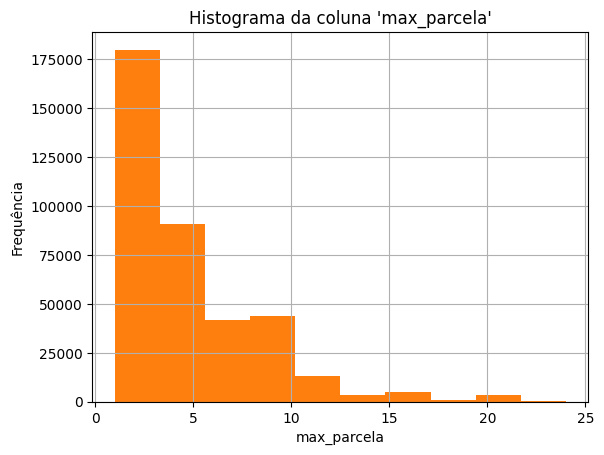

In [31]:
try:
    # Convert only the 'valor' column to pandas
    parcelas_pd = df_parcelas_max.select("max_parcela").toPandas()
    parcelas_pd = parcelas_pd[parcelas_pd["max_parcela"] > 0]
    parcelas_pd.hist(bins=50)

    plt.hist(parcelas_pd["max_parcela"].dropna())
    plt.xlabel("max_parcela")
    plt.ylabel("Frequência")
    plt.title("Histograma da coluna 'max_parcela'")
    plt.show()
except Exception as e:
    print("Erro ao gerar histograma:", e)

# Quantidade de Contratos com Quantidade de Atrasos superior > 30 dias

- quantidade de contratos com quantidade de atrasos superior a 30 dias
- status do ultimo screen shots - observar a quantidade de dias em atraso
- estatistica descritiva por contratos: min, max, media  e mediana ----> quantidade de dias de atraso
- quando ocorre o primeiro atraso, em qual parcela? ----> incluir o percentual do contrato, exemplo: 25% dos contratos ocorre o primeiro atraso em até 3 parcela..
- Boxplot de valor_parcela por inadimplente vs adimplente

inadimplência vs adimplente
  - valor_juros × inadimplência
  - qtd_parcelas × inadimplência
  - valor_amortizacao × inadimplência

- *Sazonalidade* : Inadimplência por mês - qual o mês ocorre?
- Correlação entre as variaveis  (VIF)  (Variance Inflation Factor) ----> Multicolinariedade
- quantidade de contratos por hash_id: usuarios com mais de um contrato tem chance de ter inadimplencia menor?
- quantidade de contratos por id_contrato_pai:
-

In [17]:
parcelas_main.show(5, truncate=False)

+--------------------------------------+--------------+---------------+-------+---------+------------------------------+------------+-------------+------------+-----------+-----------+-----------------+----------+--------------+------------------+--------------------------+----------------+--------------------------------------+-------+------------------+-------------------------------+--------------------------------------+--------------------------------------+---------------+----------------------------------------------------------------+
|id_contrato                           |data_pagamento|data_vencimento|valor  |valor_iof|valor_financiado_principal_iof|qtd_parcelas|valor_parcela|valor_tarifa|valor_juros|valor_iof_2|valor_amortizacao|valor_pago|valor_desconto|valor_juros_atraso|valor_juros_remuneratorios|status_pagamento|id_parcela                            |parcela|qtd_dias_de_atraso|contract_installments_status_id|uuid_cliente                          |id_contrato_original   

In [32]:
from pyspark.sql.functions import col

parcelas_aux_validate_dates = parcelas_main.filter(col("id_contrato") == "{11A4AA20-CD2C-4321-BD2A-EB697CA90C5F}")
parcelas_aux_validate_dates.orderBy("data_vencimento").show(100, truncate=False)

+--------------------------------------+--------------+---------------+------+---------+------------------------------+------------+-------------+------------+-----------+-----------+-----------------+----------+--------------+------------------+--------------------------+----------------+--------------------------------------+-------+------------------+-------------------------------+--------------------------------------+--------------------------------------+---------------+----------------------------------------------------------------+
|id_contrato                           |data_pagamento|data_vencimento|valor |valor_iof|valor_financiado_principal_iof|qtd_parcelas|valor_parcela|valor_tarifa|valor_juros|valor_iof_2|valor_amortizacao|valor_pago|valor_desconto|valor_juros_atraso|valor_juros_remuneratorios|status_pagamento|id_parcela                            |parcela|qtd_dias_de_atraso|contract_installments_status_id|uuid_cliente                          |id_contrato_original     